In [1]:
# ============================================================
# FASE 2: PERSIAPAN DAN EKSPLORASI DATA
# Project: Customer Intelligence - Online Retail II
# Teknik: RFM + K-Means & Market Basket Analysis
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================
# LANGKAH 1: LOAD DATASET
# ============================================================
# Download dari Kaggle: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
# File: online_retail_II.xlsx (ada 2 sheet: Year 2009-2010 & Year 2010-2011)
 
df = pd.read_csv('online_retail_II.csv')
print("=" * 60)
print("INFORMASI AWAL DATASET")
print("=" * 60)
print(f"Total baris     : {df.shape[0]:,}") #0 baris
print(f"Total kolom     : {df.shape[1]}") #1 jumlah atribut/fitur
print(f"\nKolom          : {list(df.columns)}") #menampilkan nama kolom
print(f"\nTipe data:\n{df.dtypes}") #menampilkan tipe data 
print(f"\nContoh data:\n{df.head()}") #menampilkan dataset teratas

INFORMASI AWAL DATASET
Total baris     : 1,067,371
Total kolom     : 8

Kolom          : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Tipe data:
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

Contoh data:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0

In [3]:
# ============================================================
# LANGKAH 2: Exploratory Data Analysis (EDA)
# ============================================================
print("\n" + "=" * 60)
print("EKSPLORASI AWAL DATA")
print("=" * 60)
print(f"\nMissing Values:\n{df.isnull().sum()}") #cek jumlah data yang kosong/missingvalue
print(f"\nDuplikat: {df.duplicated().sum():,}") #menghitung jumlah yang duplikat
print(f"\nStatistik deskriptif:\n{df.describe()}") #Statistik deskriptif data


EKSPLORASI AWAL DATA

Missing Values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplikat: 34,335

Statistik deskriptif:
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1.235531e+02    1697.464450
min   -8.099500e+04 -5.359436e+04   12346.000000
25%    1.000000e+00  1.250000e+00   13975.000000
50%    3.000000e+00  2.100000e+00   15255.000000
75%    1.000000e+01  4.150000e+00   16797.000000
max    8.099500e+04  3.897000e+04   18287.000000


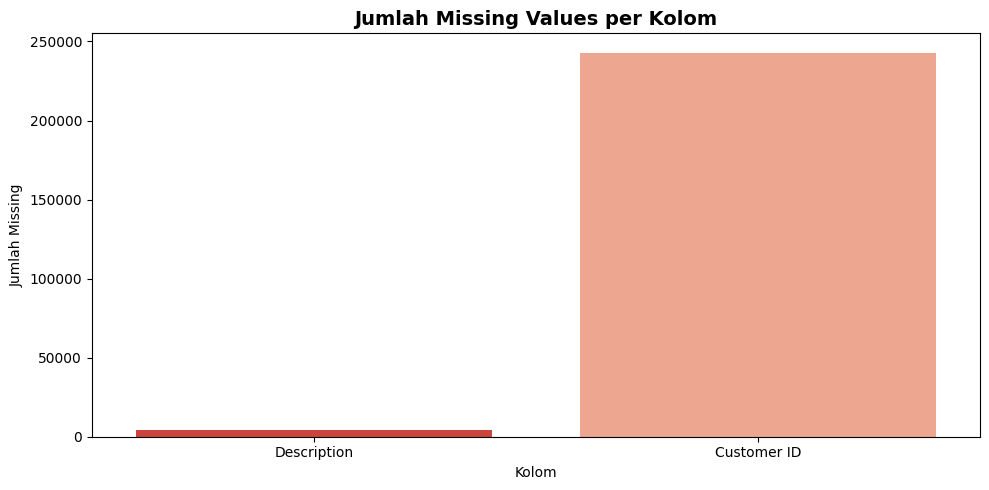

In [4]:
# Visualisasi missing values
plt.figure(figsize=(10, 5))
missing = df.isnull().sum()
missing = missing[missing > 0] #Hanya mengambil kolom yang memiliki missing value.
sns.barplot(x=missing.index, y=missing.values, palette='Reds_r') #garfik batang
plt.title('Jumlah Missing Values per Kolom', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Missing')
plt.xlabel('Kolom')
plt.tight_layout()
#plt.savefig('eda_missing_values.png', dpi=150) #Menyimpan grafik menjadi file PNG
plt.show()

In [5]:
# ============================================================
# LANGKAH 3: DATA CLEANING
# ============================================================
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)
 
df_clean = df.copy() #Agar data asli tidak berubah.
 
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Customer ID']) #Menghapus Customer ID kosong, karena rfm butuh indentitas pelanggan
print(f"Hapus missing CustomerID : {before - len(df_clean):,} baris")
 
before = len(df_clean)
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')] #Menghapus transaksi cancel, huruf c berarti transkasi di batalin
print(f"Hapus transaksi batal    : {before - len(df_clean):,} baris")
 
before = len(df_clean)
df_clean = df_clean[df_clean['Quantity'] > 0] #Menghapus Quantity negatif, Karena pembelian harus bernilai positif.
print(f"Hapus Quantity <= 0      : {before - len(df_clean):,} baris")
 
before = len(df_clean)
df_clean = df_clean[df_clean['Price'] > 0] #hapus price negatf, Harga harus lebih besar dari nol.
print(f"Hapus Price <= 0         : {before - len(df_clean):,} baris")
 
before = len(df_clean)
df_clean = df_clean.drop_duplicates() #menghapus dupplikay
print(f"Hapus duplikat           : {before - len(df_clean):,} baris")
 
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])# Konversi tanggal, Mengubah tipe data menjadi datetime.
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int).astype(str)
 
print(f"\nData bersih: {len(df_clean):,} baris ({len(df_clean)/len(df)*100:.1f}% dari data asli)")


DATA CLEANING
Hapus missing CustomerID : 243,007 baris
Hapus transaksi batal    : 18,744 baris
Hapus Quantity <= 0      : 0 baris
Hapus Price <= 0         : 71 baris
Hapus duplikat           : 26,124 baris

Data bersih: 779,425 baris (73.0% dari data asli)


In [6]:
# ============================================================
# LANGKAH 4: FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)
 
df_clean['TotalPrice']  = df_clean['Quantity'] * df_clean['Price'] #contoh Total Penjualan 5 × £2.50 = £12.50
df_clean['Year']        = df_clean['InvoiceDate'].dt.year #Mengambil tahun transaksi.
df_clean['Month']       = df_clean['InvoiceDate'].dt.month #Mengambil bulan transaksi.
df_clean['Hour']        = df_clean['InvoiceDate'].dt.hour #Mengambil jam transaksi.
df_clean['DayOfWeek']   = df_clean['InvoiceDate'].dt.day_name()
 
print("Kolom baru: TotalPrice, Year, Month, Hour, DayOfWeek")
print(df_clean[['Invoice', 'Quantity', 'Price', 'TotalPrice', 'DayOfWeek']].head())


FEATURE ENGINEERING
Kolom baru: TotalPrice, Year, Month, Hour, DayOfWeek
  Invoice  Quantity  Price  TotalPrice DayOfWeek
0  489434        12   6.95        83.4   Tuesday
1  489434        12   6.75        81.0   Tuesday
2  489434        12   6.75        81.0   Tuesday
3  489434        48   2.10       100.8   Tuesday
4  489434        24   1.25        30.0   Tuesday


# RECENCY, FREQUENCY, MONETARY

In [7]:
# ============================================================
# LANGKAH 5: RFM FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 60)
print("RFM FEATURE ENGINEERING")
print("=" * 60)
 
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1) #Menentukan tanggal referensi
print(f"Tanggal referensi: {reference_date.date()}") #Misal transaksi terakhir:2011-12-09 Maka:2011-12-10
 
rfm = df_clean.groupby('Customer ID').agg(      #Mengelompokkan berdasarkan pelanggan.
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days), #Menghitung berapa hari sejak transaksi terakhir.
    Frequency = ('Invoice', 'nunique'), #Menghitung jumlah invoice unik
    Monetary  = ('TotalPrice', 'sum') #Total uang yang dibelanjakan pelanggan. Contoh:100 + 200 + 300 = 600
).reset_index()
 
print(f"\nTotal pelanggan unik: {len(rfm):,}")
print(f"\nStatistik RFM:\n{rfm[['Recency','Frequency','Monetary']].describe().round(2)}")
rfm.to_csv('rfm_raw.csv', index=False)
print("RFM mentah disimpan: rfm_raw.csv")


RFM FEATURE ENGINEERING
Tanggal referensi: 2011-12-10

Total pelanggan unik: 5,878

Statistik RFM:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04
RFM mentah disimpan: rfm_raw.csv


In [8]:
# ============================================================
# LANGKAH 6: NORMALISASI RFM
# ============================================================
rfm['R_log'] = np.log1p(rfm['Recency'])
rfm['F_log'] = np.log1p(rfm['Frequency'])
rfm['M_log'] = np.log1p(rfm['Monetary'])
 
scaler = StandardScaler()
rfm[['R_scaled', 'F_scaled', 'M_scaled']] = scaler.fit_transform(
    rfm[['R_log', 'F_log', 'M_log']]
)
 
rfm.to_csv('rfm_scaled.csv', index=False)
print("RFM ternormalisasi disimpan: rfm_scaled.csv")

"""Masalah:

Monetary bisa sampai ribuan.

Frequency hanya puluhan.

Perlu diseimbangkan."""

RFM ternormalisasi disimpan: rfm_scaled.csv


'Masalah:\n\nMonetary bisa sampai ribuan.\n\nFrequency hanya puluhan.\n\nPerlu diseimbangkan.'

StandardScaler menggunakan rumus:

z=
σ
x−μ
	​


di mana:

x = nilai data
μ = rata-rata kolom
σ = standar deviasi kolom

Hasilnya:

Rata-rata seluruh kolom = 0
Standar deviasi seluruh kolom = 1

Bukan setiap nilai menjadi 0 atau 1.

Perhatikan:

nilai di bawah rata-rata → negatif
nilai di atas rata-rata → positif
yang tepat di rata-rata → 0

karena K-Means sensitif terhadap skala data dan StandardScaler membuat setiap fitur memiliki rata-rata 0 dan standar deviasi 1. Jadi output R_scaled, F_scaled, dan M_scaled

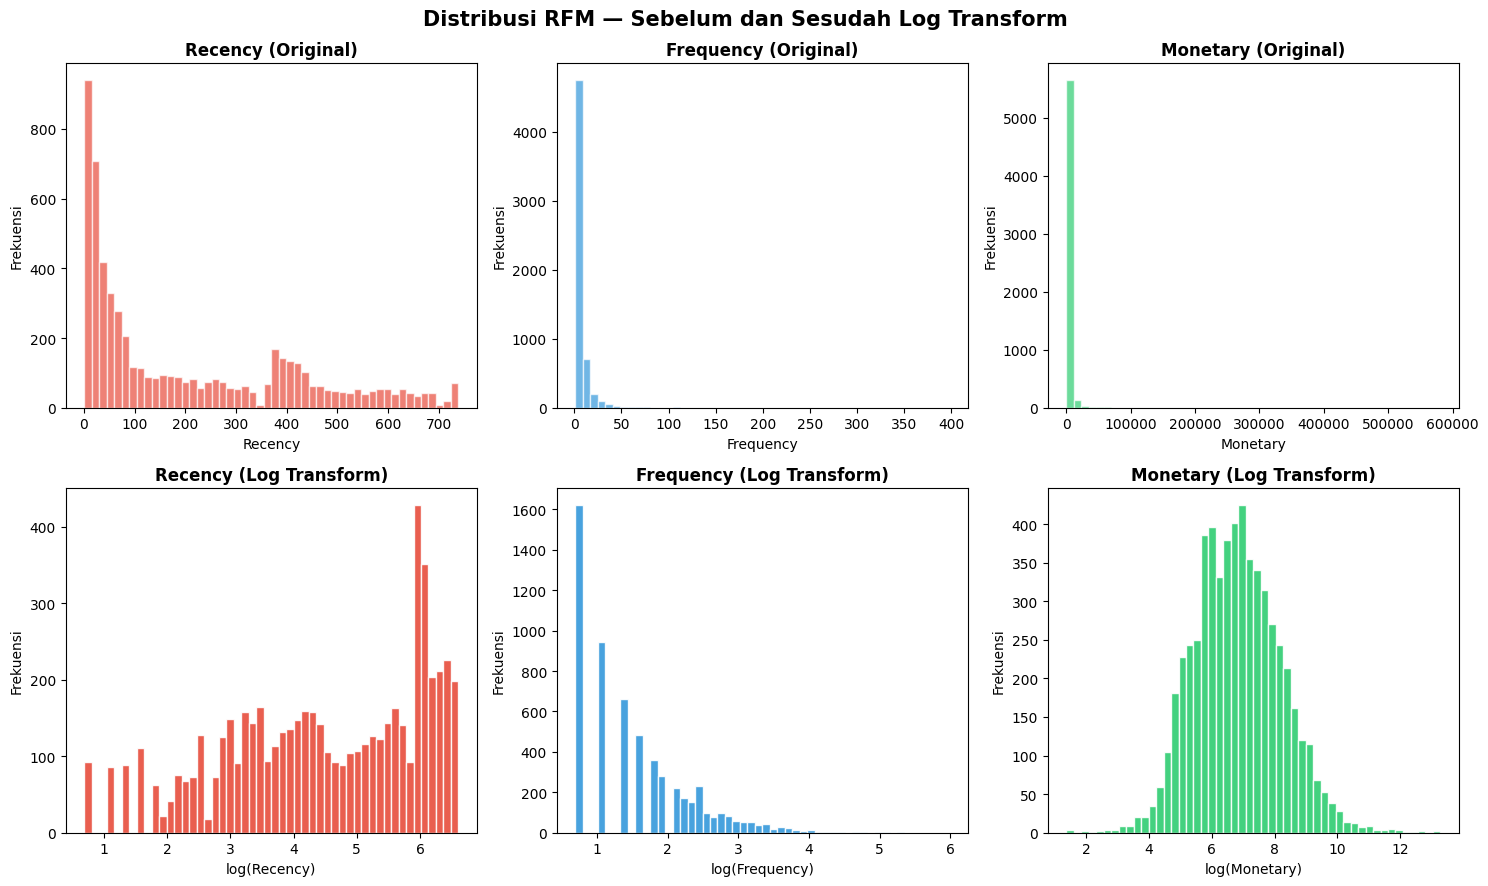

'Baris atas:\n\nRecency asli\nFrequency asli\nMonetary asli\n\nBaris bawah:\n\nRecency log\nFrequency log\nMonetary log'

In [9]:
# ============================================================
# LANGKAH 7: VISUALISASI DISTRIBUSI RFM
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9)) #Membuat 6 grafik.
fig.suptitle('Distribusi RFM — Sebelum dan Sesudah Log Transform',
             fontsize=15, fontweight='bold')
 
metrics_raw = ['Recency', 'Frequency', 'Monetary']
metrics_log = ['R_log', 'F_log', 'M_log']
colors      = ['#e74c3c', '#3498db', '#2ecc71']
 
for i, (raw, log, color) in enumerate(zip(metrics_raw, metrics_log, colors)):
    axes[0, i].hist(rfm[raw], bins=50, color=color, alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{raw} (Original)', fontweight='bold')
    axes[0, i].set_xlabel(raw); axes[0, i].set_ylabel('Frekuensi')
 
    axes[1, i].hist(rfm[log], bins=50, color=color, alpha=0.9, edgecolor='white')
    axes[1, i].set_title(f'{raw} (Log Transform)', fontweight='bold')
    axes[1, i].set_xlabel(f'log({raw})'); axes[1, i].set_ylabel('Frekuensi')
 
plt.tight_layout()
plt.show()

'''Baris atas:

Recency asli
Frequency asli
Monetary asli

Baris bawah:

Recency log
Frequency log
Monetary log'''

In [10]:
# ============================================================
# LANGKAH 8: PERSIAPAN BASKET UNTUK MBA
# ============================================================
print("\n" + "=" * 60)
print("PERSIAPAN DATA MARKET BASKET ANALYSIS")
print("=" * 60)
 
df_uk = df_clean[df_clean['Country'] == 'United Kingdom'].copy() #Biasanya dataset retail ini didominasi UK.
print(f"Transaksi UK: {len(df_uk):,} baris")
 
basket = (df_uk.groupby(['Invoice', 'Description'])['Quantity'] #Setiap baris = transaksi. Setiap kolom = produk.
          .sum().unstack(fill_value=0))
 
basket_encoded = basket.map(lambda x: 1 if x > 0 else 0) #ON HOT ENCODING Karena MBA hanya perlu: Dibeli atau tidak
 
print(f"Dimensi basket: {basket_encoded.shape[0]:,} transaksi x {basket_encoded.shape[1]:,} produk")
basket_encoded.to_csv('basket_encoded.csv')
print("Basket encoded disimpan: basket_encoded.csv") #File ini akan dipakai pada algoritma:Apriori, FP-Growth
 


PERSIAPAN DATA MARKET BASKET ANALYSIS
Transaksi UK: 700,388 baris
Dimensi basket: 33,541 transaksi x 5,249 produk
Basket encoded disimpan: basket_encoded.csv


In [11]:
# ============================================================
# RINGKASAN FASE 2
# ============================================================
print("\n" + "=" * 60)
print("RINGKASAN FASE 2")
print("=" * 60)
print(f"Data awal          : {len(df):,} baris")
print(f"Data bersih        : {len(df_clean):,} baris")
print(f"Pelanggan unik     : {len(rfm):,} pelanggan")
print(f"File output        : rfm_raw.csv, rfm_scaled.csv, basket_encoded.csv")
print(f"\nFase 2 SELESAI. Lanjut ke Fase 3: Pemodelan K-Means & FP-Growth")


RINGKASAN FASE 2
Data awal          : 1,067,371 baris
Data bersih        : 779,425 baris
Pelanggan unik     : 5,878 pelanggan
File output        : rfm_raw.csv, rfm_scaled.csv, basket_encoded.csv

Fase 2 SELESAI. Lanjut ke Fase 3: Pemodelan K-Means & FP-Growth


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans #Import K-Means dan Evaluasi
from sklearn.metrics import silhouette_score, silhouette_samples #Mengukur kualitas cluster.

import sys
import subprocess
try:
    from mlxtend.frequent_patterns import fpgrowth, association_rules #digunakan untuk Market Basket Analysis
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend"])
    from mlxtend.frequent_patterns import fpgrowth, association_rules

import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')

| Score       | Interpretasi                  |
| ----------- | ----------------------------- |
| mendekati 1 | cluster sangat baik           |
| sekitar 0   | cluster saling tumpang tindih |
| negatif     | cluster buruk                 |


# BAGIAN A: K-MEANS CLUSTERING

In [13]:
# Load data RFM yang sudah dinormalisasi (dari Fase 2)
rfm = pd.read_csv('rfm_scaled.csv')
X = rfm[['R_scaled', 'F_scaled', 'M_scaled']].values #Mengambil hanya fitur yang akan digunakan.

membaca hasil fase 2 misalnya
| Customer ID | R_scaled | F_scaled | M_scaled |
| ----------- | -------- | -------- | -------- |
| 12346       | 0.8      | -0.2     | 1.5      |
| 12347       | -2.1     | 0.8      | 0.3      |



[A1] Elbow Method...


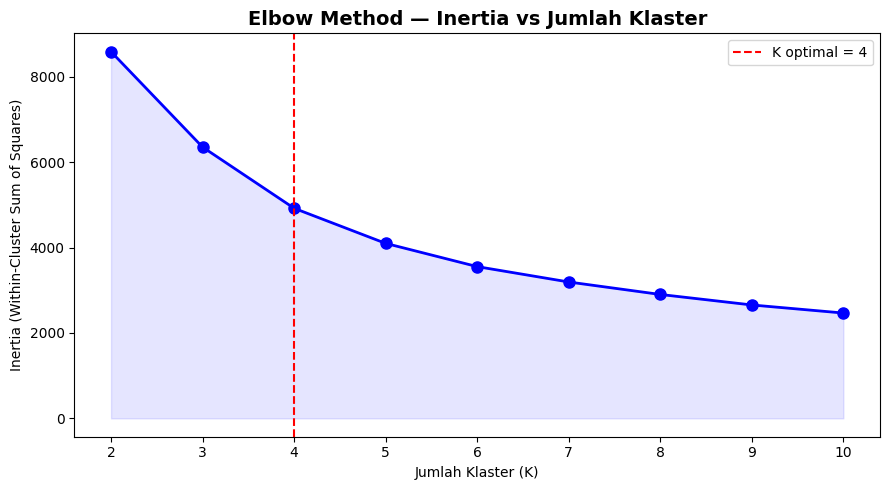

In [14]:
# ----------------------------------------------------------
# A1. ELBOW METHOD — Menentukan jumlah klaster optimal
# ----------------------------------------------------------
print("\n[A1] Elbow Method...")
 
inertia = []
K_range = range(2, 11) #Rentang K, K = 2,3,4,5,6,7,8,9,10
 
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10) #n_clusters Jumlah cluster. random_state=42 Agar hasil selalu sama. 
    #n_init=10 K-Means mencoba 10 kali centroid awal lalu memilih hasil terbaik.
    km.fit(X)
    inertia.append(km.inertia_) #Inertia = total jarak dalam cluster. Semakin kecil semakin baik.
 
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.fill_between(K_range, inertia, alpha=0.1, color='blue')
plt.axvline(x=4, color='red', linestyle='--', label='K optimal = 4')
plt.title('Elbow Method — Inertia vs Jumlah Klaster', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.legend()
plt.tight_layout()
plt.show()
# plt.savefig('elbow_method.png', dpi=150)
# plt.close()
# print("Plot disimpan: elbow_method.png")
 

Mengapa K = 4 Dipilih?

Dalam Elbow Method, jumlah klaster optimal dipilih pada titik "siku" (elbow), yaitu titik ketika penurunan inertia yang awalnya tajam mulai melambat secara signifikan.

jadi yang Jumlah klaster optimal berdasarkan Elbow Method adalah 4 klaster.


[A2] Silhouette Score per K...
  K=2: Silhouette Score = 0.4386
  K=3: Silhouette Score = 0.3477
  K=4: Silhouette Score = 0.3650
  K=5: Silhouette Score = 0.3425
  K=6: Silhouette Score = 0.3348
  K=7: Silhouette Score = 0.3066
  K=8: Silhouette Score = 0.3033
  K=9: Silhouette Score = 0.2925
  K=10: Silhouette Score = 0.2905

K terbaik berdasarkan Silhouette: K = 2


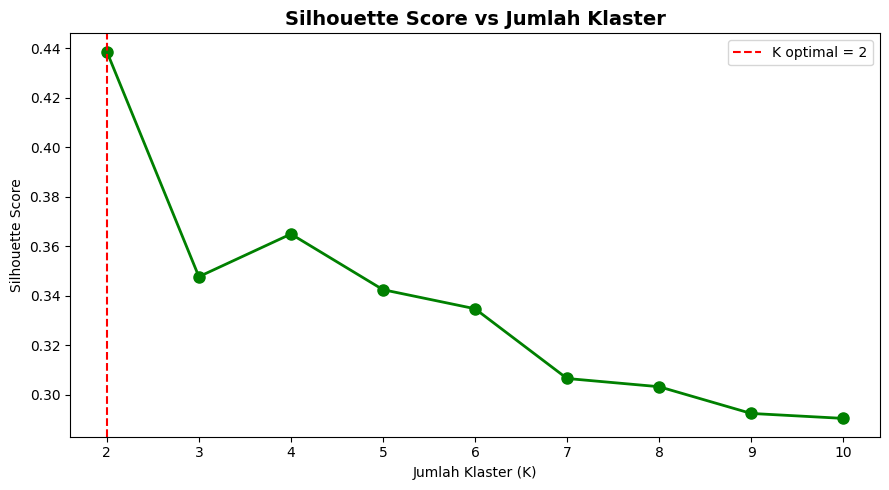

In [15]:
# ----------------------------------------------------------
# A2. ELBOW KDANG SUKA SUBJECKTIF JADI PERLU VALIDASI SILHOUETTE SCORE — Validasi klaster
# ----------------------------------------------------------
print("\n[A2] Silhouette Score per K...")
 
sil_scores = []
for k in K_range: #Loop semua K
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels) #Mengukur: Seberapa dekat data dengan cluster sendiri dibanding cluster lain.
    sil_scores.append(score) #Simpan score
    print(f"  K={k}: Silhouette Score = {score:.4f}") #Tampilkan score
 
best_k = K_range[np.argmax(sil_scores)]
print(f"\nK terbaik berdasarkan Silhouette: K = {best_k}")
 
plt.figure(figsize=(9, 5))
plt.plot(K_range, sil_scores, 'go-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'K optimal = {best_k}')
plt.title('Silhouette Score vs Jumlah Klaster', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()
# plt.savefig('silhouette_scores.png', dpi=150)
# plt.close()
# print("Plot disimpan: silhouette_scores.png")

maka secara murni berdasarkan metrik Silhouette Score, jumlah cluster terbaik adalah: K=2

karena memiliki nilai Silhouette Score terbesar: 0.4386

In [16]:
# ----------------------------------------------------------
# A3. FIT K-MEANS dengan K optimal
# ----------------------------------------------------------
print(f"\n[A3] Training K-Means dengan K={best_k}...")
 
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X) #Melakukan:Training K-Means, Memberi label cluster
 
print(f"Distribusi klaster:\n{rfm['Cluster'].value_counts().sort_index()}") #Menghitung jumlah pelanggan tiap cluster.


[A3] Training K-Means dengan K=2...
Distribusi klaster:
Cluster
0    3558
1    2320
Name: count, dtype: int64


Setelah algoritma K-Means dijalankan, seluruh 5.878 pelanggan berhasil dikelompokkan menjadi 2 segmen:
TOTAL ADA 5878 pelanggan
| Cluster   | Jumlah Pelanggan | Persentase |
| --------- | ---------------: | ---------: |
| 0         |            3.558 |     60,53% |
| 1         |            2.320 |     39,47% |
| **Total** |        **5.878** |   **100%** |


3558 / 5878 * 100
# 60.53%

2320 / 5878 * 100
# 39.47%

In [17]:
# ----------------------------------------------------------
# A4. PROFIL KLASTER — Interpretasi tiap segmen
# ----------------------------------------------------------
print("\n[A4] Profil Klaster (nilai rata-rata RFM asli)...")
 
profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)#Menghitung Rata-rata RFM per Cluster
profile['Count'] = rfm.groupby('Cluster').size()
profile['Pct']   = (profile['Count'] / len(rfm) * 100).round(1)
print(profile)


[A4] Profil Klaster (nilai rata-rata RFM asli)...
         Recency  Frequency  Monetary  Count   Pct
Cluster                                           
0         299.65       2.10    614.34   3558  60.5
1          50.56      12.72   6546.97   2320  39.5


Hasil segmentasi menggunakan algoritma K-Means dengan K=2 menghasilkan dua kelompok pelanggan. Cluster 0 terdiri dari 3.558 pelanggan (60,5%) dengan rata-rata Recency sebesar 299,65 hari, Frequency 2,10 transaksi, dan Monetary 614,34. Karakteristik ini menunjukkan bahwa pelanggan pada cluster tersebut cenderung tidak aktif dan memiliki nilai transaksi yang rendah. Sementara itu, Cluster 1 terdiri dari 2.320 pelanggan (39,5%) dengan rata-rata Recency 50,56 hari, Frequency 12,72 transaksi, dan Monetary 6.546,97. Cluster ini merepresentasikan pelanggan loyal dan bernilai tinggi karena lebih aktif bertransaksi serta memberikan kontribusi pendapatan yang signifikan.

C 0 Interpretasi Bisnis:

Cluster 0 merupakan pelanggan bernilai rendah (Low Value Customers) atau pelanggan yang berisiko churn (At-Risk Customers). Mereka jarang bertransaksi, sudah lama tidak melakukan pembelian, dan memberikan kontribusi pendapatan yang relatif kecil.

Jumlah:

3.558 pelanggan (60,5%)

C 1 Interpretasi Bisnis:

Cluster 1 merupakan pelanggan bernilai tinggi (High Value Customers atau Loyal Customers). Mereka aktif bertransaksi, sering melakukan pembelian, dan menghasilkan nilai penjualan yang jauh lebih besar dibandingkan pelanggan pada cluster lainnya.

Jumlah:

2.320 pelanggan (39,5%)

In [18]:
# Labeling segmen berdasarkan profil
# (sesuaikan label setelah melihat nilai rata-rata)
segment_map = {}
for cluster_id, row in profile.iterrows():
    r, f, m = row['Recency'], row['Frequency'], row['Monetary']
    if r < 50 and f > 10 and m > 3000:
        segment_map[cluster_id] = 'Champions' #Segmen terbaik.
    elif r < 100 and f > 5: #Masih cukup aktif
        segment_map[cluster_id] = 'Loyal Customers'
    elif r > 200 and f <= 3: #Sudah lama tidak belanja
        segment_map[cluster_id] = 'At-Risk / Lost'
    else:
        segment_map[cluster_id] = 'Potential Loyalist'
 
rfm['Segment'] = rfm['Cluster'].map(segment_map)
print(f"\nPemetaan Segmen:\n{rfm['Segment'].value_counts()}")
 
rfm.to_csv('rfm_clustered.csv', index=False)
print("Hasil klaster disimpan: rfm_clustered.csv")


Pemetaan Segmen:
Segment
At-Risk / Lost     3558
Loyal Customers    2320
Name: count, dtype: int64
Hasil klaster disimpan: rfm_clustered.csv


Interpretasi Bisnis
1. At-Risk / Lost Customers (60,5%)

Karakteristik berdasarkan profil sebelumnya:

Recency = 299,65 hari
Frequency = 2,10 transaksi
Monetary = 614,34

Artinya:

Sudah lama tidak berbelanja.
Frekuensi pembelian rendah.
Total pengeluaran relatif kecil.

Strategi yang dapat dilakukan:

Mengirim email promosi atau voucher diskon.
Program reaktivasi pelanggan.
Reminder produk yang pernah dibeli.
Kampanye "We Miss You".

2. Loyal Customers (39,5%)

Karakteristik:

Recency = 50,56 hari
Frequency = 12,72 transaksi
Monetary = 6.546,97

Artinya:

Masih aktif berbelanja.
Frekuensi transaksi tinggi.
Kontribusi pendapatan sangat besar.

Strategi yang dapat dilakukan:

Program loyalitas.
Membership atau VIP program.
Early access untuk produk baru.
Reward point dan cashback.

    Hasil segmentasi pelanggan menggunakan algoritma K-Means menghasilkan dua kelompok pelanggan. Segmen At-Risk / Lost terdiri dari 3.558 pelanggan (60,5%) yang memiliki frekuensi pembelian rendah, nilai transaksi rendah, dan sudah lama tidak melakukan pembelian. Segmen Loyal Customers terdiri dari 2.320 pelanggan (39,5%) yang memiliki frekuensi pembelian tinggi, nilai transaksi besar, dan masih aktif bertransaksi. Hasil ini menunjukkan bahwa sebagian besar pelanggan berada pada kategori berisiko churn, sehingga perusahaan perlu menerapkan strategi retensi pelanggan untuk meningkatkan loyalitas dan mendorong pelanggan kembali melakukan pembelian.

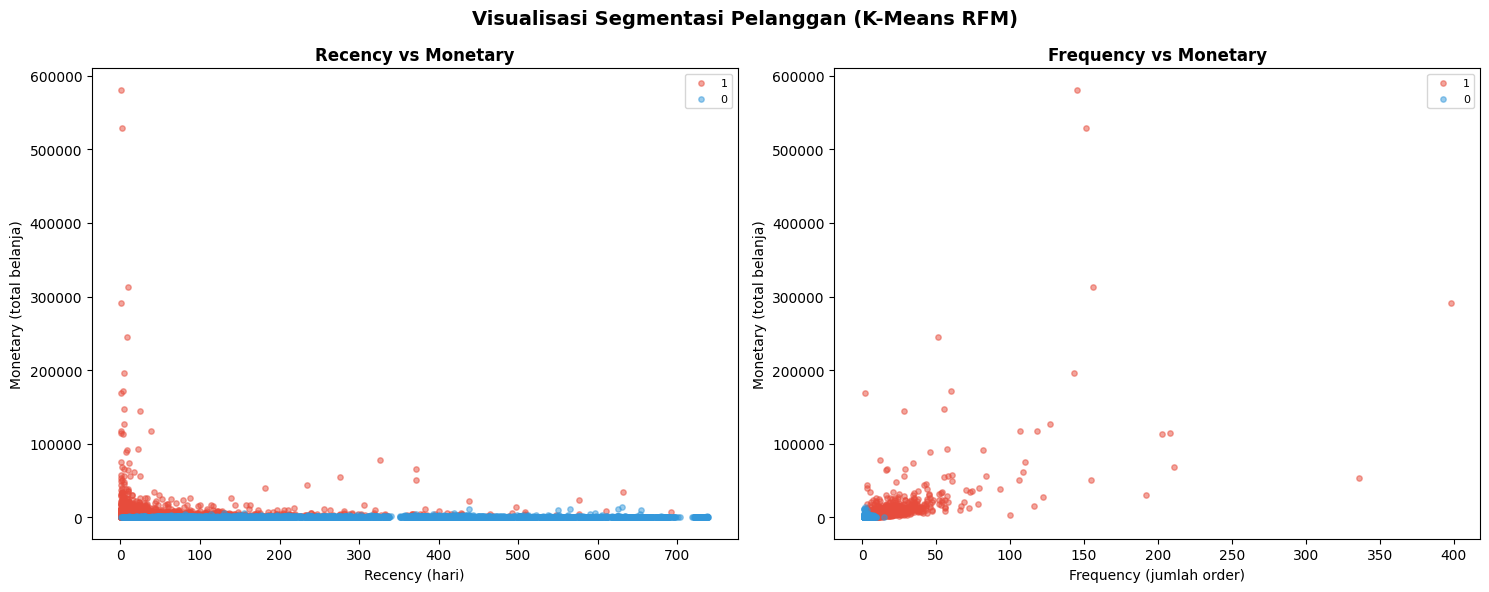

In [19]:
# ----------------------------------------------------------
# A5. VISUALISASI KLASTER
# ----------------------------------------------------------
# Scatter plot 2D: Recency vs Monetary
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_seg = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
 
for ax, (x_col, y_col, xlabel, ylabel) in zip(axes, [
    ('Recency', 'Monetary', 'Recency (hari)', 'Monetary (total belanja)'),
    ('Frequency', 'Monetary', 'Frequency (jumlah order)', 'Monetary (total belanja)')
]):
    for i, seg in enumerate(rfm['Cluster'].unique()):
        mask = rfm['Cluster'] == seg
        ax.scatter(rfm[mask][x_col], rfm[mask][y_col],
                   c=colors_seg[i], label=seg, alpha=0.5, s=15)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f'{x_col} vs {y_col}', fontweight='bold')
    ax.legend(fontsize=8)
 
fig.suptitle('Visualisasi Segmentasi Pelanggan (K-Means RFM)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# plt.savefig('cluster_scatter2.png', dpi=150)
# plt.close()
# print("Plot scatter klaster disimpan: cluster_scatter2.png")

- Grafik Kiri: Recency vs Monetary

Sumbu X (Recency)
Semakin ke kiri  = pelanggan baru berbelanja
Semakin ke kanan = pelanggan sudah lama tidak berbelanja

Sumbu Y (Monetary)

Semakin ke atas = total belanja semakin besar
Semakin ke bawah = total belanja semakin kecil

- Grafik Kanan: Frequency vs Monetary

Sumbu X (Frequency)

Semakin ke kanan = semakin sering belanja
Semakin ke kiri  = semakin jarang belanja

Sumbu Y (Monetary)

Semakin ke atas = semakin besar total belanja

<h6>Visualisasi hasil clustering menunjukkan bahwa pelanggan pada Cluster 1 (merah) cenderung memiliki nilai Frequency dan Monetary yang lebih tinggi serta nilai Recency yang lebih rendah dibandingkan Cluster 0 (biru). Hal ini mengindikasikan bahwa pelanggan Cluster 1 merupakan pelanggan loyal dan bernilai tinggi karena masih aktif bertransaksi dan memberikan kontribusi pendapatan yang besar. Sebaliknya, pelanggan Cluster 0 memiliki nilai Frequency dan Monetary yang rendah serta nilai Recency yang tinggi, sehingga dapat dikategorikan sebagai pelanggan berisiko churn (At-Risk / Lost Customers).

| Warna    | Segmen          | Karakteristik                                            |
| -------- | --------------- | -------------------------------------------------------- |
| 🔴 Merah | Loyal Customers | Sering belanja, aktif, nilai transaksi tinggi            |
| 🔵 Biru  | At-Risk / Lost  | Jarang belanja, lama tidak aktif, nilai transaksi rendah |


<Figure size 1000x500 with 0 Axes>

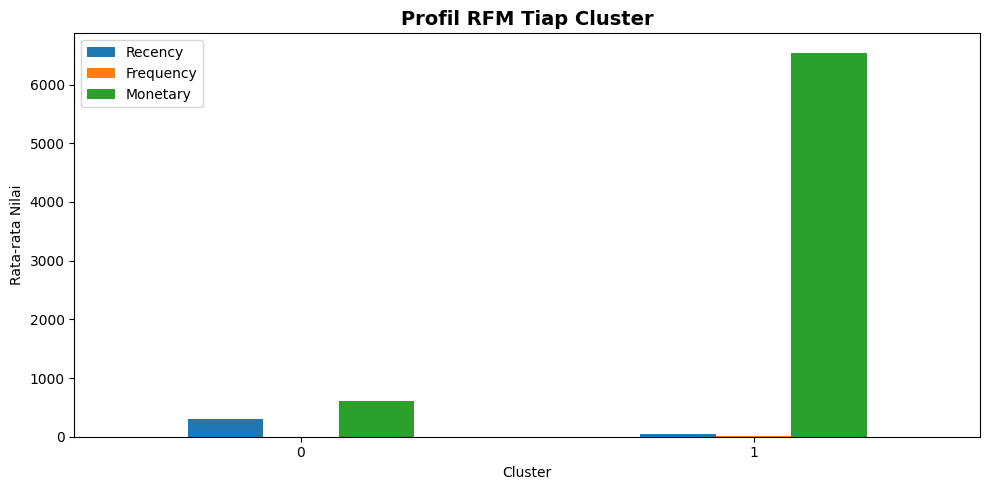

In [20]:
# ----------------------------------------------------------
# A5. BAR CHART PROFIL CLUSTER
# ----------------------------------------------------------

profile_plot = profile[['Recency','Frequency','Monetary']]

plt.figure(figsize=(10,5))

profile_plot.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Profil RFM Tiap Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Rata-rata Nilai')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

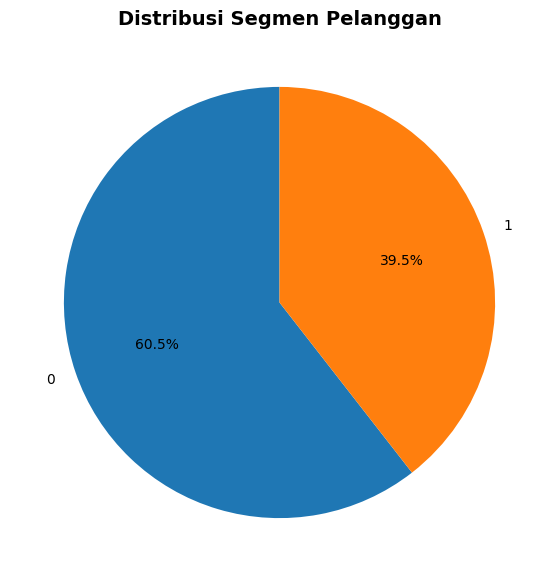

In [21]:
# ----------------------------------------------------------
# A6. DISTRIBUSI SEGMENTASI PELANGGAN
# ----------------------------------------------------------

segment_counts = rfm['Cluster'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribusi Segmen Pelanggan',
          fontsize=14,
          fontweight='bold')

plt.show()

- At-Risk / Lost      60.5%

- Loyal Customers     39.5%

# radar gaperlu opsional aja

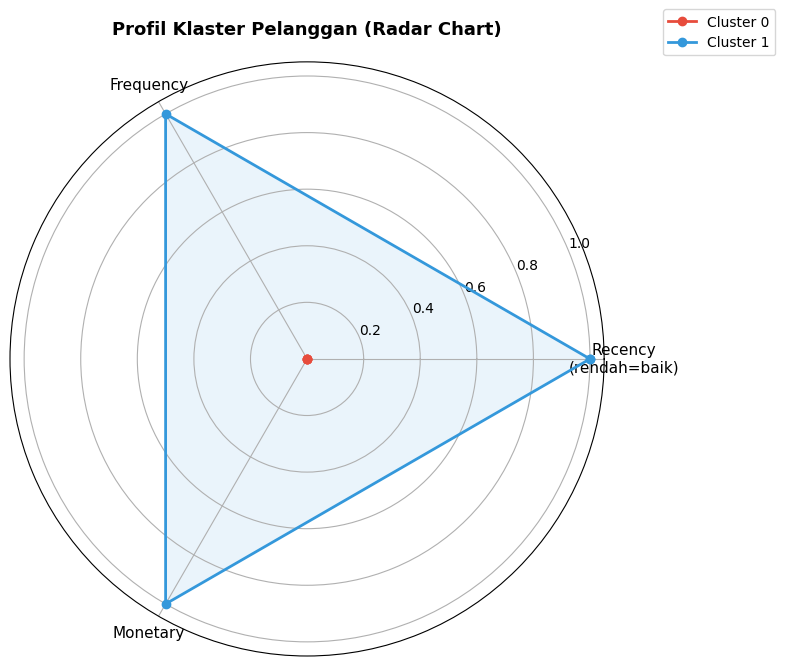

In [22]:
# Radar chart profil klaster
from matplotlib.patches import FancyArrowPatch #untuk membuat panah atau anotasi khusus pada grafik.
 
categories = ['Recency\n(rendah=baik)', 'Frequency', 'Monetary']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
 
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Normalisasi untuk radar
profile_norm = profile[['Recency', 'Frequency', 'Monetary']].copy()
profile_norm['Recency'] = 1 / (profile_norm['Recency'] + 1)  # invert recency
for col in profile_norm.columns:
    profile_norm[col] = (profile_norm[col] - profile_norm[col].min()) / \
                        (profile_norm[col].max() - profile_norm[col].min() + 1e-9)
 
for i, (idx, row) in enumerate(profile_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    seg_name = f'Cluster {idx}'
    ax.plot(angles, values, 'o-', linewidth=2, label=seg_name, color=colors_seg[i])
    ax.fill(angles, values, alpha=0.1, color=colors_seg[i])
 
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Profil Klaster Pelanggan (Radar Chart)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()
# plt.savefig('cluster_radar.png', dpi=150)
# plt.close()
# print("Radar chart disimpan: cluster_radar.png")

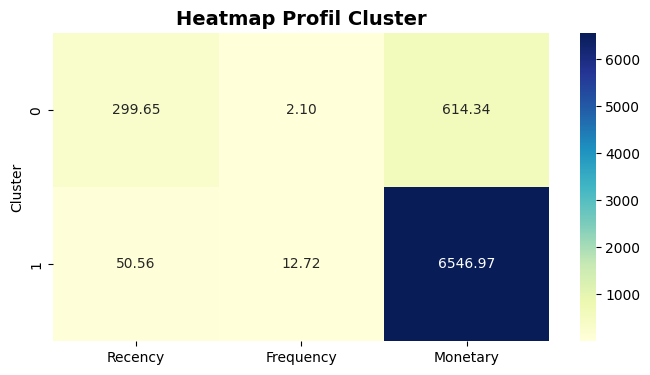

In [23]:
# ----------------------------------------------------------
# A7. HEATMAP PROFIL CLUSTER
# ----------------------------------------------------------

plt.figure(figsize=(8,4))

sns.heatmap(
    profile[['Recency','Frequency','Monetary']],
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Heatmap Profil Cluster',
          fontsize=14,
          fontweight='bold')

plt.show()

Heatmap ini digunakan untuk melihat rata-rata nilai RFM pada setiap cluster. Semakin gelap warnanya, semakin besar nilainya.
| Cluster | Recency | Frequency | Monetary |
| ------- | ------: | --------: | -------: |
| 0       |  299.65 |      2.10 |   614.34 |
| 1       |   50.56 |     12.72 |  6546.97 |


| Metrik                       | Cluster 0 (At-Risk / Lost) | Cluster 1 (Loyal Customers) |
| ---------------------------- | -------------------------: | --------------------------: |
| **Recency (hari)**           |                     299.65 |                       50.56 |
| **Frequency (transaksi)**    |                       2.10 |                       12.72 |
| **Monetary (total belanja)** |                     614.34 |                    6,546.97 |


| Cluster                         | Karakteristik                                                                                                                                                                                                                              |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Cluster 0 (At-Risk / Lost)**  | Sudah lama tidak bertransaksi (299,65 hari), frekuensi pembelian sangat rendah (2,10 transaksi), dan nilai belanja rendah (614,34). Pelanggan dalam segmen ini berisiko churn atau telah berhenti berbelanja.                              |
| **Cluster 1 (Loyal Customers)** | Masih aktif berbelanja (50,56 hari sejak transaksi terakhir), memiliki frekuensi pembelian tinggi (12,72 transaksi), dan memberikan kontribusi pendapatan besar (6.546,97). Segmen ini merupakan pelanggan loyal yang perlu dipertahankan. |


In [24]:
# ============================================================
# BAGIAN B: MARKET BASKET ANALYSIS (FP-Growth)
# ============================================================
print("\n" + "=" * 60)
print("BAGIAN B: MARKET BASKET ANALYSIS (FP-Growth)")
print("=" * 60)
 
# Load basket encoded (dari Fase 2)
basket_encoded = pd.read_csv('basket_encoded.csv', index_col=0) #nge redirect hasil data yang udh di encoding
basket_bool = basket_encoded.astype(bool)
 
print(f"Dimensi basket: {basket_bool.shape}")


BAGIAN B: MARKET BASKET ANALYSIS (FP-Growth)
Dimensi basket: (33541, 5249)


Tujuannya untuk mencari produk yang sering dibeli bersamaan oleh pelanggan.

- 1 = produk dibeli
- 0 = produk tidak dibeli

In [25]:
 #---------------------------------------------------------
# B1. FP-GROWTH — Frequent Itemsets
# ----------------------------------------------------------
print("\n[B1] Mining Frequent Itemsets (min_support=0.02)...")
 
frequent_itemsets = fpgrowth(basket_bool, min_support=0.02, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"Jumlah frequent itemsets: {len(frequent_itemsets):,}")
print(f"\nTop 10 itemset paling sering:")
print(frequent_itemsets.sort_values('support', ascending=False).head(10).to_string())


[B1] Mining Frequent Itemsets (min_support=0.02)...
Jumlah frequent itemsets: 180

Top 10 itemset paling sering:
      support                                         itemsets  length
12   0.140157  frozenset({WHITE HANGING HEART T-LIGHT HOLDER})       1
116  0.085150            frozenset({REGENCY CAKESTAND 3 TIER})       1
1    0.074655       frozenset({ASSORTED COLOUR BIRD ORNAMENT})       1
129  0.071286             frozenset({JUMBO BAG RED RETROSPOT})       1
71   0.057869                       frozenset({PARTY BUNTING})       1
59   0.056707             frozenset({LUNCH BAG  BLACK SKULL.})       1
56   0.054948        frozenset({REX CASH+CARRY JUMBO SHOPPER})       1
2    0.052712            frozenset({HOME BUILDING BLOCK WORD})       1
126  0.051579               frozenset({HEART OF WICKER SMALL})       1
127  0.051310               frozenset({HEART OF WICKER LARGE})       1


Artinya:

Algoritma FP-Growth menemukan 180 itemset (produk atau kombinasi produk) yang muncul pada minimal 2% transaksi (min_support=0.02).

Dengan kata lain, ada 180 pola pembelian yang cukup sering terjadi sehingga dianggap signifikan untuk dianalisis lebih lanjut.

| Kolom    | Arti                                               |
| -------- | -------------------------------------------------- |
| support  | Persentase transaksi yang mengandung item tersebut |
| itemsets | Produk yang ditemukan                              |
| length   | Jumlah produk dalam itemset                        |

# contoh
- support = 0.140157
- itemsets = WHITE HANGING HEART T-LIGHT HOLDER
- length = 1
Artinya: Produk tersebut muncul pada 14,02% dari seluruh transaksi dan merupakan item tunggal (length = 1).


Hasil proses FP-Growth dengan minimum support sebesar 2% menghasilkan 180 frequent itemsets. Berdasarkan 10 itemset dengan support tertinggi, produk yang paling sering muncul dalam transaksi adalah WHITE HANGING HEART T-LIGHT HOLDER dengan nilai support sebesar 14,02%, diikuti oleh REGENCY CAKESTAND 3 TIER sebesar 8,52% dan ASSORTED COLOUR BIRD ORNAMENT sebesar 7,47%. Temuan ini menunjukkan bahwa produk dekorasi rumah dan tas belanja merupakan kategori produk yang paling diminati pelanggan. Seluruh itemset pada peringkat 10 teratas merupakan item tunggal (length = 1), sehingga diperlukan analisis association rules untuk mengidentifikasi hubungan pembelian antar produk.

In [26]:
#----------------------------------------------------------
# B2. ASSOCIATION RULES
# ----------------------------------------------------------
print("\n[B2] Generate Association Rules (min_confidence=0.3)...") #Sistem mulai membuat aturan asosiasi dengan confidence minimal 30%.
 
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)#Mengubah frequent itemsets menjadi aturan, hanya aturan confidence minimak 30% yang di simpan
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False) #mengurutkan berdasarkan lift tertinggi -> terendah
 
print(f"Jumlah rules dengan lift > 1: {len(rules):,}")
print(f"\nTop 10 rules terbaik (lift tertinggi):")
cols_show = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(rules[cols_show].head(10).to_string())
 
rules.to_csv('association_rules.csv', index=False)
print("Association rules disimpan: association_rules.csv")


[B2] Generate Association Rules (min_confidence=0.3)...
Jumlah rules dengan lift > 1: 15

Top 10 rules terbaik (lift tertinggi):
                                       antecedents                                     consequents   support  confidence       lift
6      frozenset({STRAWBERRY CERAMIC TRINKET BOX})     frozenset({SWEETHEART CERAMIC TRINKET BOX})  0.022540    0.456246  13.949822
5      frozenset({SWEETHEART CERAMIC TRINKET BOX})     frozenset({STRAWBERRY CERAMIC TRINKET BOX})  0.022540    0.689152  13.949822
9         frozenset({WOODEN FRAME ANTIQUE WHITE })  frozenset({WOODEN PICTURE FRAME WHITE FINISH})  0.028979    0.565445  11.772558
8   frozenset({WOODEN PICTURE FRAME WHITE FINISH})        frozenset({WOODEN FRAME ANTIQUE WHITE })  0.028979    0.603352  11.772558
1            frozenset({LOVE BUILDING BLOCK WORD})           frozenset({HOME BUILDING BLOCK WORD})  0.022778    0.528354  10.023487
0            frozenset({HOME BUILDING BLOCK WORD})           frozenset({LOVE B

# Cara baca kolom 
| Kolom       | Arti                                               |
| ----------- | -------------------------------------------------- |
| Antecedents | Produk awal (jika membeli ini...)                  |
| Consequents | Produk tujuan (...maka cenderung membeli ini)      |
| Support     | Persentase transaksi yang mengandung kedua produk  |
| Confidence  | Peluang membeli consequent jika membeli antecedent |
| Lift        | Kekuatan hubungan antar produk                     |


#===============================================================

rules 1 lift tertinggi
| Metrik     | Nilai                          |
| ---------- | ------------------------------ |
| Antecedent | STRAWBERRY CERAMIC TRINKET BOX |
| Consequent | SWEETHEART CERAMIC TRINKET BOX |
| Support    | 2.25%                          |
| Confidence | 45.62%                         |
| Lift       | 13.95                          |

#==============================================
 rules 2
 | Metrik     | Nilai                          |
| ---------- | ------------------------------ |
| Antecedent | SWEETHEART CERAMIC TRINKET BOX |
| Consequent | STRAWBERRY CERAMIC TRINKET BOX |
| Confidence | 68.92%                         |
| Lift       | 13.95                          |

#==============================================
rules 3&4
| Produk                            |
| --------------------------------- |
| WOODEN FRAME ANTIQUE WHITE        |
| WOODEN PICTURE FRAME WHITE FINISH |

confidence :                    lift : 11.77
- 56.5%
- 60.3%

#==============================================
rules 5&6
| Produk                   |
| ------------------------ |
| LOVE BUILDING BLOCK WORD |
| HOME BUILDING BLOCK WORD |

confidence :
- 43.2%                          lift : 10.02
- 52.8%

#==============================================
rules 7&8
| Produk                |
| --------------------- |
| HEART OF WICKER LARGE |
| HEART OF WICKER SMALL |

confidence :
- 49.7%                          lift : 9.63
- 49.4%

#===============================================
rules 9&10
| Produk                    |
| ------------------------- |
| LUNCH BAG BLACK SKULL     |
| LUNCH BAG SPACEBOY DESIGN |

confidence : 
- 38.4%                          lift : 7.68 
- 43.5%

note : Hasil Association Rules menghasilkan 15 aturan dengan nilai lift lebih dari 1. Aturan dengan kekuatan hubungan tertinggi adalah antara STRAWBERRY CERAMIC TRINKET BOX dan SWEETHEART CERAMIC TRINKET BOX dengan nilai lift sebesar 13,95. Temuan ini menunjukkan bahwa pelanggan yang membeli salah satu produk memiliki kecenderungan yang sangat tinggi untuk membeli produk pasangannya. Selain itu, beberapa pasangan produk dekorasi rumah, bingkai foto, dan lunch bag juga menunjukkan hubungan pembelian yang kuat. Hasil ini dapat dimanfaatkan untuk strategi cross-selling, bundling produk, rekomendasi produk otomatis, dan pengaturan tata letak produk guna meningkatkan nilai transaksi pelanggan.

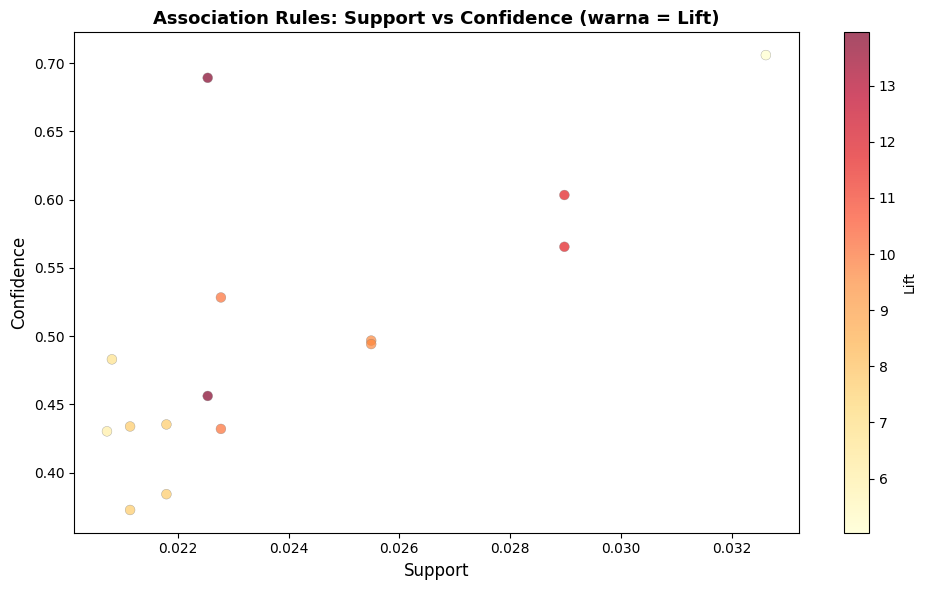

In [27]:
 #---------------------------------------------------------
# B3. VISUALISASI ASSOCIATION RULES
# ----------------------------------------------------------
# Support vs Confidence scatter dengan warna Lift
plt.figure(figsize=(10, 6)) # lebar 10inc, tinggi 6inc
scatter = plt.scatter(rules['support'], rules['confidence'],
                      c=rules['lift'], cmap='YlOrRd', #Artinya warna ditentukan oleh nilai Lift.
                      alpha=0.7, s=50, edgecolors='grey', linewidth=0.3)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Association Rules: Support vs Confidence (warna = Lift)',
          fontsize=13, fontweight='bold') # Memberi judul grafik dengan ukuran font 13 dan cetak tebal (bold)
plt.tight_layout()
plt.show()
# plt.savefig('mba_scatter.png', dpi=150)
# plt.close()
# print("Plot MBA scatter disimpan: mba_scatter.png")

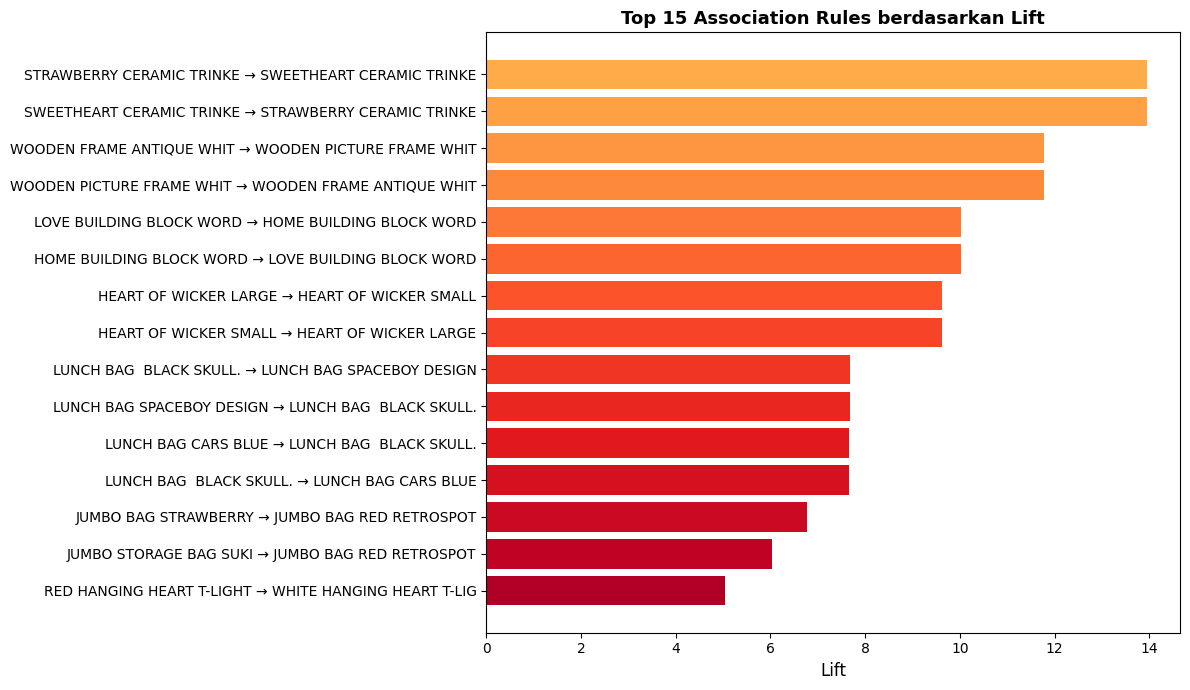

In [28]:
# Top 15 rules bar chart (lift)
top15 = rules.head(15).copy()
top15['rule'] = top15.apply(
    lambda r: f"{list(r['antecedents'])[0][:25]} → {list(r['consequents'])[0][:25]}", axis=1
)
 
plt.figure(figsize=(12, 7))
bars = plt.barh(top15['rule'], top15['lift'], color=plt.cm.YlOrRd(
    np.linspace(0.4, 0.9, len(top15))))
plt.xlabel('Lift', fontsize=12)
plt.title('Top 15 Association Rules berdasarkan Lift', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
# plt.savefig('mba_top15_lift.png', dpi=150)
# plt.close()
# print("Plot top 15 rules disimpan: mba_top15_lift.png")

In [29]:
# ============================================================
# BAGIAN C: INTEGRASI — MBA per Segmen Pelanggan
# ============================================================
print("\n" + "=" * 60)
print("BAGIAN C: INTEGRASI K-MEANS + MBA per SEGMEN")
print("=" * 60)
 
# Load data bersih dengan CustomerID
df_clean = pd.read_csv('basket_encoded.csv', index_col=0)  # placeholder
# Catatan: untuk integrasi penuh, join rfm_clustered dengan df_clean
# menggunakan Customer ID, lalu filter basket per segmen
 
rfm_seg = pd.read_csv('rfm_clustered.csv')
 
print("\nRingkasan segmentasi + rekomendasi MBA:")
print("-" * 50)
for seg in rfm_seg['Segment'].unique():
    count = len(rfm_seg[rfm_seg['Segment'] == seg])
    pct   = count / len(rfm_seg) * 100
    print(f"Segmen '{seg}': {count:,} pelanggan ({pct:.1f}%)")
    # Rekomendasi MBA berdasarkan rules teratas untuk segmen ini
    # (dalam implementasi penuh: filter transaksi pelanggan segmen ini)
    print(f"  → Lihat top rules dari association_rules.csv untuk bundling\n")
 


BAGIAN C: INTEGRASI K-MEANS + MBA per SEGMEN

Ringkasan segmentasi + rekomendasi MBA:
--------------------------------------------------
Segmen 'Loyal Customers': 2,320 pelanggan (39.5%)
  → Lihat top rules dari association_rules.csv untuk bundling

Segmen 'At-Risk / Lost': 3,558 pelanggan (60.5%)
  → Lihat top rules dari association_rules.csv untuk bundling



In [30]:
#============================================================
# RINGKASAN FASE 3
# ============================================================
print("=" * 60)
print("RINGKASAN FASE 3")
print("=" * 60)
print(f"K-Means  : {best_k} klaster ditemukan")
print(f"Segmen   : {rfm['Segment'].unique().tolist()}")
print(f"FP-Growth: {len(frequent_itemsets):,} frequent itemsets")
print(f"Rules    : {len(rules):,} association rules (lift > 1)")
print("\nFile output:")
print("  rfm_clustered.csv        — data pelanggan + label segmen")
print("  association_rules.csv    — semua rules MBA")
print("  elbow_method.png         — plot elbow")
print("  silhouette_scores.png    — plot silhouette")
print("  cluster_scatter.png      — visualisasi segmen")
print("  cluster_radar.png        — radar chart profil")
print("  mba_scatter.png          — support vs confidence")
print("  mba_top15_lift.png       — top 15 rules")
print("\nFase 3 SELESAI. Lanjut ke Fase 4: Interpretasi & Rekomendasi Bisnis")

RINGKASAN FASE 3
K-Means  : 2 klaster ditemukan
Segmen   : ['Loyal Customers', 'At-Risk / Lost']
FP-Growth: 180 frequent itemsets
Rules    : 15 association rules (lift > 1)

File output:
  rfm_clustered.csv        — data pelanggan + label segmen
  association_rules.csv    — semua rules MBA
  elbow_method.png         — plot elbow
  silhouette_scores.png    — plot silhouette
  cluster_scatter.png      — visualisasi segmen
  cluster_radar.png        — radar chart profil
  mba_scatter.png          — support vs confidence
  mba_top15_lift.png       — top 15 rules

Fase 3 SELESAI. Lanjut ke Fase 4: Interpretasi & Rekomendasi Bisnis


In [31]:
# ============================================================
# FASE 4: INTERPRETASI & REKOMENDASI BISNIS
# Project: Customer Intelligence - Online Retail II
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [32]:
# ============================================================
# LOAD HASIL FASE 3
# ============================================================
rfm = pd.read_csv('rfm_clustered.csv')
rules = pd.read_csv('association_rules.csv')
 
# Konversi kolom frozenset dari string
import ast
rules['antecedents'] = rules['antecedents'].apply(
    lambda x: list(eval(x)) if isinstance(x, str) else x)

rules['consequents'] = rules['consequents'].apply(
    lambda x: list(eval(x)) if isinstance(x, str) else x)
 
print("=" * 60)
print("FASE 4: INTERPRETASI & REKOMENDASI BISNIS")
print("=" * 60)
print(f"Total pelanggan: {len(rfm):,}")
print(f"Total rules MBA: {len(rules):,}")
print(f"Segmen: {rfm['Segment'].unique().tolist()}")
 

FASE 4: INTERPRETASI & REKOMENDASI BISNIS
Total pelanggan: 5,878
Total rules MBA: 15
Segmen: ['Loyal Customers', 'At-Risk / Lost']


In [33]:
print(rules['antecedents'].head())

0       [STRAWBERRY CERAMIC TRINKET BOX]
1       [SWEETHEART CERAMIC TRINKET BOX]
2          [WOODEN FRAME ANTIQUE WHITE ]
3    [WOODEN PICTURE FRAME WHITE FINISH]
4             [LOVE BUILDING BLOCK WORD]
Name: antecedents, dtype: object


In [34]:
# ============================================================
# BAGIAN 1: PROFIL MENDALAM TIAP SEGMEN
# ============================================================
print("\n" + "=" * 60)
print("PROFIL MENDALAM TIAP SEGMEN")
print("=" * 60)
 
profile = rfm.groupby('Segment').agg(
    Jumlah_Pelanggan = ('Customer ID', 'count'),
    Avg_Recency      = ('Recency', 'mean'),
    Avg_Frequency    = ('Frequency', 'mean'),
    Avg_Monetary     = ('Monetary', 'mean'),
    Total_Revenue    = ('Monetary', 'sum')
).round(2)
profile['Pct_Pelanggan'] = (profile['Jumlah_Pelanggan'] / len(rfm) * 100).round(1)
profile['Pct_Revenue']   = (profile['Total_Revenue'] / rfm['Monetary'].sum() * 100).round(1)
 
print(profile.to_string())
profile.to_csv('segment_profile.csv')
print("\nProfil segmen disimpan: segment_profile.csv")


PROFIL MENDALAM TIAP SEGMEN
                 Jumlah_Pelanggan  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Pct_Pelanggan  Pct_Revenue
Segment                                                                                                               
At-Risk / Lost               3558       299.65           2.10        614.34     2185833.06           60.5         12.6
Loyal Customers              2320        50.56          12.72       6546.97    15188971.20           39.5         87.4

Profil segmen disimpan: segment_profile.csv


In [35]:
# ============================================================
# BAGIAN 2: VISUALISASI DISTRIBUSI SEGMEN
# ============================================================
colors = {
    'Champions'         : '#e74c3c',
    'Loyal Customers'   : '#3498db',
    'Potential Loyalist': '#2ecc71',
    'At-Risk / Lost'    : '#95a5a6'
}
seg_colors = [colors.get(s, '#f39c12') for s in profile.index]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribusi Segmen Pelanggan', fontsize=15, fontweight='bold')
 
# Pie chart — jumlah pelanggan
axes[0].pie(profile['Jumlah_Pelanggan'], labels=profile.index,
            autopct='%1.1f%%', colors=seg_colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Proporsi Jumlah Pelanggan', fontweight='bold')
 
# Bar chart — revenue kontribusi
axes[1].barh(profile.index, profile['Pct_Revenue'], color=seg_colors, edgecolor='white')
axes[1].set_xlabel('Kontribusi Revenue (%)')
axes[1].set_title('Kontribusi Revenue per Segmen', fontweight='bold')
for i, v in enumerate(profile['Pct_Revenue']):
    axes[1].text(v + 0.3, i, f'{v}%', va='center', fontweight='bold')
 
# Bubble chart — RFM 3D
for seg, row in profile.iterrows():
    c = colors.get(seg, '#f39c12')
    axes[2].scatter(row['Avg_Recency'], row['Avg_Monetary'],
                    s=row['Avg_Frequency'] * 80,
                    color=c, alpha=0.8, edgecolors='white', linewidth=2, label=seg)
    axes[2].annotate(seg, (row['Avg_Recency'], row['Avg_Monetary']),
                     textcoords='offset points', xytext=(8, 4), fontsize=8)
axes[2].set_xlabel('Rata-rata Recency (hari)')
axes[2].set_ylabel('Rata-rata Monetary (£)')
axes[2].set_title('Bubble Chart RFM\n(ukuran = Frequency)', fontweight='bold')
 
plt.tight_layout()
plt.savefig('segment_overview.png', dpi=150)
plt.close()
print("Plot overview segmen disimpan: segment_overview.png")

Plot overview segmen disimpan: segment_overview.png


In [36]:
# ============================================================
# BAGIAN 3: REKOMENDASI BISNIS PER SEGMEN
# ============================================================
print("\n" + "=" * 60)
print("REKOMENDASI BISNIS PER SEGMEN")
print("=" * 60)
 
rekomendasi = {
    'Champions': {
        'Deskripsi' : 'Pelanggan terbaik. Beli baru-baru ini, sering, dan nilai tinggi.',
        'Strategi'  : [
            'Program loyalitas eksklusif (VIP membership, early access)',
            'Reward cashback atau poin belanja',
            'Undang sebagai brand ambassador / program referral',
            'Penawaran produk premium dan bundling eksklusif',
            'Survei kepuasan untuk mempertahankan engagement'
        ],
        'KPI'       : 'Pertahankan retention rate > 90%, tingkatkan AOV 10-15%'
    },
    'Loyal Customers': {
        'Deskripsi' : 'Belanja rutin dan cukup sering, tapi nilai belanja bisa ditingkatkan.',
        'Strategi'  : [
            'Upselling produk dengan margin lebih tinggi',
            'Bundling cross-category berdasarkan rules MBA',
            'Email newsletter dengan rekomendasi produk personal',
            'Milestone reward (diskon setelah X transaksi)',
            'Program subscribe & save untuk produk rutin'
        ],
        'KPI'       : 'Tingkatkan Monetary rata-rata 20%, Frequency +1 order/kuartal'
    },
    'Potential Loyalist': {
        'Deskripsi' : 'Pelanggan baru atau jarang beli. Peluang besar untuk dikonversi.',
        'Strategi'  : [
            'Welcome offer atau diskon pembelian kedua',
            'Email onboarding sequence (3-5 email dalam 30 hari)',
            'Rekomendasi produk populer berdasarkan MBA',
            'Flash sale eksklusif untuk mendorong repeat purchase',
            'Free shipping threshold untuk meningkatkan basket size'
        ],
        'KPI'       : 'Konversi ke Loyal dalam 90 hari, target Frequency >= 3'
    },
    'At-Risk / Lost': {
        'Deskripsi' : 'Belum transaksi lama. Risiko churn tinggi atau sudah churn.',
        'Strategi'  : [
            'Win-back campaign: "Kami rindu kamu" + voucher diskon besar',
            'Survey alasan tidak aktif (feedback loop)',
            'Retargeting ads di media sosial',
            'Last chance offer dengan urgensi waktu terbatas',
            'Jika tidak respons dalam 180 hari, pindahkan ke inactive list'
        ],
        'KPI'       : 'Target reaktivasi 15-20% dari segmen ini dalam 3 bulan'
    }
}
 
for seg, info in rekomendasi.items():
    if seg in rfm['Segment'].unique():
        seg_data = rfm[rfm['Segment'] == seg]
        print(f"\n{'─'*55}")
        print(f"  SEGMEN: {seg.upper()}")
        print(f"{'─'*55}")
        print(f"  Deskripsi : {info['Deskripsi']}")
        print(f"  Jumlah    : {len(seg_data):,} pelanggan ({len(seg_data)/len(rfm)*100:.1f}%)")
        print(f"  Avg R/F/M : {seg_data['Recency'].mean():.0f} hari / "
              f"{seg_data['Frequency'].mean():.1f}x / £{seg_data['Monetary'].mean():.0f}")
        print(f"  Strategi  :")
        for i, s in enumerate(info['Strategi'], 1):
            print(f"    {i}. {s}")
        print(f"  KPI Target: {info['KPI']}")
 


REKOMENDASI BISNIS PER SEGMEN

───────────────────────────────────────────────────────
  SEGMEN: LOYAL CUSTOMERS
───────────────────────────────────────────────────────
  Deskripsi : Belanja rutin dan cukup sering, tapi nilai belanja bisa ditingkatkan.
  Jumlah    : 2,320 pelanggan (39.5%)
  Avg R/F/M : 51 hari / 12.7x / £6547
  Strategi  :
    1. Upselling produk dengan margin lebih tinggi
    2. Bundling cross-category berdasarkan rules MBA
    3. Email newsletter dengan rekomendasi produk personal
    4. Milestone reward (diskon setelah X transaksi)
    5. Program subscribe & save untuk produk rutin
  KPI Target: Tingkatkan Monetary rata-rata 20%, Frequency +1 order/kuartal

───────────────────────────────────────────────────────
  SEGMEN: AT-RISK / LOST
───────────────────────────────────────────────────────
  Deskripsi : Belum transaksi lama. Risiko churn tinggi atau sudah churn.
  Jumlah    : 3,558 pelanggan (60.5%)
  Avg R/F/M : 300 hari / 2.1x / £614
  Strategi  :
    1. Win-b

In [37]:
# ============================================================
# BAGIAN 4: TOP BUNDLING RECOMMENDATIONS (dari MBA)
# ============================================================
print("\n" + "=" * 60)
print("REKOMENDASI BUNDLING PRODUK (dari MBA)")
print("=" * 60)
 
top_rules = rules.nlargest(20, 'lift').copy()
top_rules['antecedents_str'] = top_rules['antecedents'].apply(
    lambda x: ', '.join(x) if isinstance(x, list) else str(x))
top_rules['consequents_str'] = top_rules['consequents'].apply(
    lambda x: ', '.join(x) if isinstance(x, list) else str(x))
 
print(f"\nTop 10 Rekomendasi Bundling:")
print(f"{'No':<4} {'Jika Beli':<40} {'Rekomendasikan':<40} {'Lift':>6} {'Conf':>6}")
print("-" * 100)
for i, row in top_rules.head(10).iterrows():
    print(f"{i+1:<4} {row['antecedents_str'][:38]:<40} "
          f"{row['consequents_str'][:38]:<40} "
          f"{row['lift']:>6.2f} {row['confidence']:>6.2f}")
 
# Visualisasi top bundling
fig, ax = plt.subplots(figsize=(13, 7))
top10 = top_rules.head(10)
y_labels = [f"{a[:30]} → {c[:30]}"
            for a, c in zip(top10['antecedents_str'], top10['consequents_str'])]
 
bars = ax.barh(y_labels, top10['lift'],
               color=plt.cm.YlOrRd(np.linspace(0.4, 0.9, 10)),
               edgecolor='white')
ax.set_xlabel('Lift', fontsize=12)
ax.set_title('Top 10 Rekomendasi Bundling Produk (berdasarkan Lift)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
 
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"conf={row['confidence']:.2f}", va='center', fontsize=9)
 
plt.tight_layout()
plt.savefig('bundling_recommendations.png', dpi=150)
plt.close()
print("\nPlot bundling disimpan: bundling_recommendations.png")


REKOMENDASI BUNDLING PRODUK (dari MBA)

Top 10 Rekomendasi Bundling:
No   Jika Beli                                Rekomendasikan                             Lift   Conf
----------------------------------------------------------------------------------------------------
1    STRAWBERRY CERAMIC TRINKET BOX           SWEETHEART CERAMIC TRINKET BOX            13.95   0.46
2    SWEETHEART CERAMIC TRINKET BOX           STRAWBERRY CERAMIC TRINKET BOX            13.95   0.69
3    WOODEN FRAME ANTIQUE WHITE               WOODEN PICTURE FRAME WHITE FINISH         11.77   0.57
4    WOODEN PICTURE FRAME WHITE FINISH        WOODEN FRAME ANTIQUE WHITE                11.77   0.60
5    LOVE BUILDING BLOCK WORD                 HOME BUILDING BLOCK WORD                  10.02   0.53
6    HOME BUILDING BLOCK WORD                 LOVE BUILDING BLOCK WORD                  10.02   0.43
7    HEART OF WICKER LARGE                    HEART OF WICKER SMALL                      9.63   0.50
8    HEART OF WICKER 

In [38]:
# ============================================================
# BAGIAN 5: ACTION PLAN (Timeline)
# ============================================================
print("\n" + "=" * 60)
print("ACTION PLAN — ROADMAP IMPLEMENTASI")
print("=" * 60)
 
action_plan = [
    ('Bulan 1', 'Quick Win',
     'Champions',
     'Aktivasi VIP program, kirim reward ekslusif top 10% pelanggan'),
    ('Bulan 1', 'Quick Win',
     'At-Risk / Lost',
     'Kirim win-back email + voucher diskon 20% batas waktu 30 hari'),
    ('Bulan 2', 'Growth',
     'Loyal Customers',
     'Bundling cross-sell berbasis top MBA rules, email campaign'),
    ('Bulan 2', 'Growth',
     'Potential Loyalist',
     'Onboarding sequence 5 email, free shipping threshold'),
    ('Bulan 3', 'Optimize',
     'Semua Segmen',
     'Evaluasi KPI, refresh segmentasi, A/B test kampanye'),
    ('Bulan 3', 'Optimize',
     'Champions',
     'Referral program launch, co-create produk baru'),
]
 
print(f"\n{'Waktu':<12} {'Fase':<12} {'Segmen Target':<22} {'Aksi'}")
print("-" * 90)
for waktu, fase, segmen, aksi in action_plan:
    print(f"{waktu:<12} {fase:<12} {segmen:<22} {aksi}")


ACTION PLAN — ROADMAP IMPLEMENTASI

Waktu        Fase         Segmen Target          Aksi
------------------------------------------------------------------------------------------
Bulan 1      Quick Win    Champions              Aktivasi VIP program, kirim reward ekslusif top 10% pelanggan
Bulan 1      Quick Win    At-Risk / Lost         Kirim win-back email + voucher diskon 20% batas waktu 30 hari
Bulan 2      Growth       Loyal Customers        Bundling cross-sell berbasis top MBA rules, email campaign
Bulan 2      Growth       Potential Loyalist     Onboarding sequence 5 email, free shipping threshold
Bulan 3      Optimize     Semua Segmen           Evaluasi KPI, refresh segmentasi, A/B test kampanye
Bulan 3      Optimize     Champions              Referral program launch, co-create produk baru


In [39]:
# ============================================================
# BAGIAN 6: SUMMARY DASHBOARD (text)
# ============================================================
print("\n" + "=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)
 
total_rev = rfm['Monetary'].sum()
champ_rev = rfm[rfm['Segment']=='Champions']['Monetary'].sum() if 'Champions' in rfm['Segment'].unique() else 0
 
print(f"""
TEMUAN UTAMA:
─────────────────────────────────────────────────────
• {len(rfm):,} pelanggan berhasil disegmentasi ke {rfm['Segment'].nunique()} kelompok
• Total revenue dataset: £{total_rev:,.0f}
• Champions menyumbang {champ_rev/total_rev*100:.1f}% revenue meski hanya sebagian kecil pelanggan
• {len(rules):,} association rules ditemukan dengan lift > 1
• Peluang bundling: produk dengan lift tinggi dapat meningkatkan basket size
 
IMPLIKASI STRATEGIS:
─────────────────────────────────────────────────────
1. Fokuskan budget retensi pada segmen Champions & Loyal
2. Gunakan MBA rules untuk personalisasi rekomendasi produk
3. Win-back campaign untuk At-Risk sebelum mereka fully churn
4. Dashboard real-time untuk monitor pergeseran segmen per bulan
""")
 
print("Fase 4 SELESAI. Output:")
print("  segment_profile.csv         — profil lengkap tiap segmen")
print("  segment_overview.png        — visualisasi distribusi segmen")
print("  bundling_recommendations.png — top bundling dari MBA")
print("\nLanjut ke Fase 6: Penulisan Artikel Ilmiah")


EXECUTIVE SUMMARY

TEMUAN UTAMA:
─────────────────────────────────────────────────────
• 5,878 pelanggan berhasil disegmentasi ke 2 kelompok
• Total revenue dataset: £17,374,804
• Champions menyumbang 0.0% revenue meski hanya sebagian kecil pelanggan
• 15 association rules ditemukan dengan lift > 1
• Peluang bundling: produk dengan lift tinggi dapat meningkatkan basket size
 
IMPLIKASI STRATEGIS:
─────────────────────────────────────────────────────
1. Fokuskan budget retensi pada segmen Champions & Loyal
2. Gunakan MBA rules untuk personalisasi rekomendasi produk
3. Win-back campaign untuk At-Risk sebelum mereka fully churn
4. Dashboard real-time untuk monitor pergeseran segmen per bulan

Fase 4 SELESAI. Output:
  segment_profile.csv         — profil lengkap tiap segmen
  segment_overview.png        — visualisasi distribusi segmen
  bundling_recommendations.png — top bundling dari MBA

Lanjut ke Fase 6: Penulisan Artikel Ilmiah
